## CMPINF 2100 Week 07 - Supplemental Reading

### Uncorrelated Vs Highly Correlated Vs Anti-Correlated

This report generates random numbers from **Multi-Variate Normal (MVN)** distributions to illustrate what uncorrelated variables look like compared to highly positively correlated and "highly" negative correlated variables. The MVN distribution is discussed in more details in CMPINF 2120. At present, what matters is that you qualitatively understand the difference between positive correlation, negative correlation, and zero correlation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Set random seed

In [2]:
rg = np.random.default_rng(2100)

## Simulated Data

We will generate random observations of 2 variables. Each variable will have a marginal standard normal distribution. The standard normal is a special name to a Gaussian with mean 0 and standard deviation1. We will generate 100 rnadom observation of the 2 variables.

Defind the mean vector as a 1D NumPy array of zeros.

In [3]:
num_x = 2

mean_vector = np.zeros( num_x)

## Uncorrelated variables

Let's first generate random observations for **uncorrelated** normally distributed variables. The covariance matrix for the uncorrelated or **zero correlation** case is dfined below

In [4]:
cov_matrix_rho_zero = np.identity( num_x )

The covariance has as many rows and columns as variables

In [5]:
cov_matrix_rho_zero.shape

(2, 2)

The uncorrelated case has a covariance matrix with two sets fo terms. The main diagonal has ONES because standard normal assumes the marginal variance is 1. TH off-diagonal terms are ZERO because the covariance is zero

In [6]:
cov_matrix_rho_zero

array([[1., 0.],
       [0., 1.]])

Let's now generate the random observations

In [8]:
x_rho_zero_mat = rg.multivariate_normal(mean_vector, cov_matrix_rho_zero, size=100)

Object is NumPy array

In [9]:
print(type(x_rho_zero_mat))

<class 'numpy.ndarray'>


Let's convert the 2D NumPy array inot a DataFrame. The column names are defined using a list comprehension to be x01 and x02

In [10]:
x_rho_zero_df = pd.DataFrame(x_rho_zero_mat, columns=['x%02d' % (d+1) for d in range(num_x)]) 

In [11]:
x_rho_zero_df

,x01,x02
0,1.024252,-1.733671
1,-0.089294,-1.093748
2,0.320995,-1.103206
3,-0.775994,-0.329677
4,-1.450625,1.069088
...,...,...
95,0.288779,-2.248282
96,1.665049,1.021603
97,0.048026,0.276395
98,0.275114,0.834191


**IMPORTANT**: Right now the primary point is **NOT** how the random numbers were generated from the Multivariate Normal (MVN) random number generator. CMPINF 2120 discusses the MVN in much more details. The main point right now is that you are working with 2 continuous variables which were created with ZERO correlation.

Let's explore the marginal distributions and the relationship between the two variables eith a pairs plot. The marginal histogram reveal the distributions are roughly symmetric around zero. How would you descrive the scatter plots? Is there a clear **direction** or **trend** between the two variales? Or, are the observations seemingly randomly located?

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


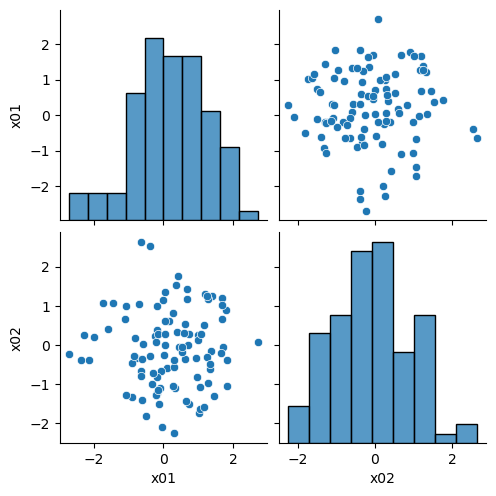

In [12]:
sns.pairplot( data = x_rho_zero_df )
plt.show()

We know that the ovservations were generated assuming zero correlation between the two variables. However, let's calculate the **empirical** or **sample** correlation matrix. After all, this is what you would do when exploring data. You do **not** know the correlation matrix that generated the data. You **must** calculate it from the data that you have. As shown below the sample corrlation between `x01` and `x02` is not identically zero, but it is quite close to zero

In [14]:
x_rho_zero_df.corr()

,x01,x02
x01,1.000000,0.007904
x02,0.007904,1.000000


We can visualize the correlation matrix as a heat mpa in a corrplot! The fact that the two variables are uncorrelated is represented by the GREY off-diagonal tiles because the consistent color bar bounds of -1 and +1 are used with a diverging color palette!

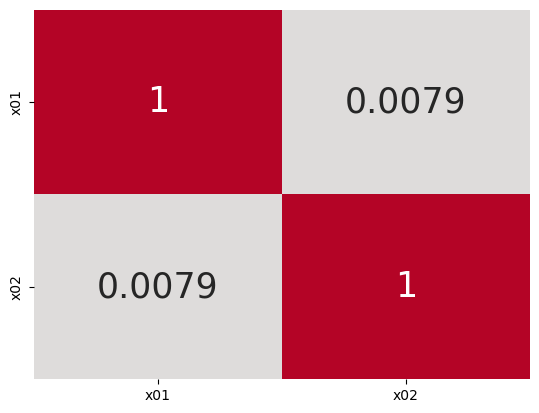

In [17]:
fig, ax = plt.subplots()

sns.heatmap(data = x_rho_zero_df.corr(),
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm', cbar=False,
            annot=True, annot_kws={'size': 25},
            ax=ax)
plt.show()

Thus, scatter plots that do have a clear "direction" are associated with near zero correlation!

## Highly Positive correlated variables

However, the easiest way to understand what zero correlation "look like" is to examine what highly correlated scatter plots look like. Let's specify the covariance matrix such that the correlation is vary hight between the two variables. The cell below creates a covariance matrix where the correlation coefficient is 0.9 between the two variables. Do you see how the 2D NumPy does not have zeros on the off-diagonal elements? That is because the two variables are not uncorrelated! Please note, the correlation matrix and covariance matrix are the same in this case because the two variables have marginal variances of 1.

In [18]:
cov_matrix_rho_high = np.array([[1,0.9],[0.9,1]])
print(cov_matrix_rho_high)

[[1.  0.9]
 [0.9 1. ]]


Let's now generate random observations using the highly correlated distribution.

In [19]:
x_rho_high_mat = rg.multivariate_normal(mean_vector, cov_matrix_rho_high, size=100)

Convert to a DataFrame using the same naming convention we used previously

In [20]:
x_rho_high_df = pd.DataFrame(x_rho_high_mat, columns=['x%02d' % (d+1) for d in range(num_x)])

The pairs shows that the two variables increase together! Threre is a clear **direction** in the scatter plots! There are **no** observations in teh lower right corner or the upper left corner.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


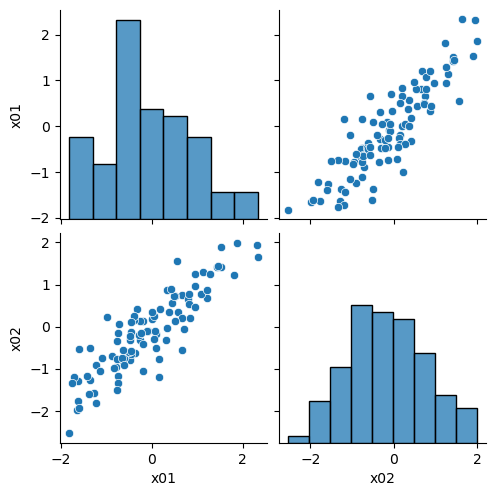

In [21]:
sns.pairplot( data = x_rho_high_df )
plt.show()

Why there are no observations in the lower right corner? The scatter plot is created with the Seabon AXIS LEVEL function below. Vertical and horizondtal reference lines are included to denote high positive values of `x01` and low negative values of `x02`, respectively. The intersection of the lines forms a patch in the lower right hand corner. No observations are located within that patch! That is because the lower right hand corner consists of low `x02` values and hight `x01` values. The highly positive correlation between the two variables means such conditions are NOT LIKELY! Large values of `x01` are obaserved WITH large values of `x02`. Likewise, small values of `x01` are observed with small values of `x02`. The two variables MOVE together. Increasing (decreasing) one variable is associated with increasing (decreasing) the other!

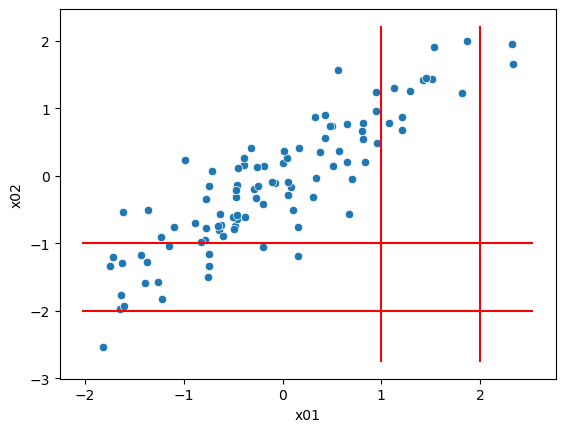

In [25]:
fig, ax = plt.subplots()

sns.scatterplot( data = x_rho_high_df, x='x01', y='x02', ax = ax )

ax.hlines(y=[-1, -2], xmin= ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red')

ax.vlines([1, 2], ymin = ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red')

plt.show()

The sample correlation is high between the `01` and `02`!

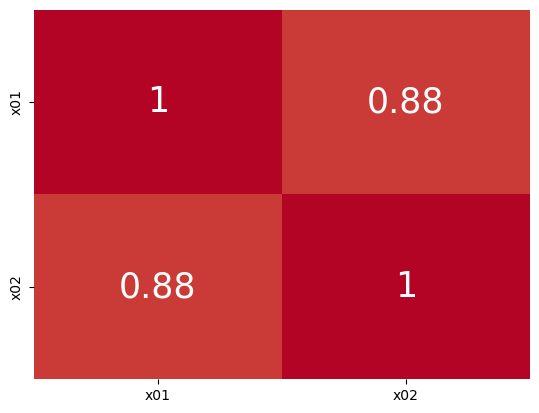

In [29]:
fig, ax = plt.subplots()

sns.heatmap( data = x_rho_high_df.corr(),
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm', cbar=False,
            annot=True, annot_kws={'size': 25},
            ax=ax)
plt.show()

Thus, clear positive relatinships/trends between the variables are associated with correlation coefficients near 1

## "Highly" Negatively or Anti Correlated Variables

Let's now see what ANTI correlation looks like. Specify the covariance matrix with anti related variables. "Anti" or "negative" relatinship means that incresing one variable is associated with decreasing the other variable. THe covariance matrix is specified below with -0.9 in the off-diagonal elements

In [30]:
cov_matrix_rho_neg = np.array([[1, -0.9],[-0.9,1]])
print(cov_matrix_rho_neg)

[[ 1.  -0.9]
 [-0.9  1. ]]


Generate the random observations

In [32]:
x_rho_neg_mat = rg.multivariate_normal(mean_vector, cov_matrix_rho_neg, size=100)

Convert to a DataFrame

In [33]:
x_rho_neg_df = pd.DataFrame(x_rho_neg_mat, columns=['x'+str(d+1).zfill(2) for d in range(num_x)])

The pairs plot shows that the two variables move opposite each other! There is a clear **direction** in the scatter plots, but that direction is DIFFERENT from what we saw with the highly positively correlated variables.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


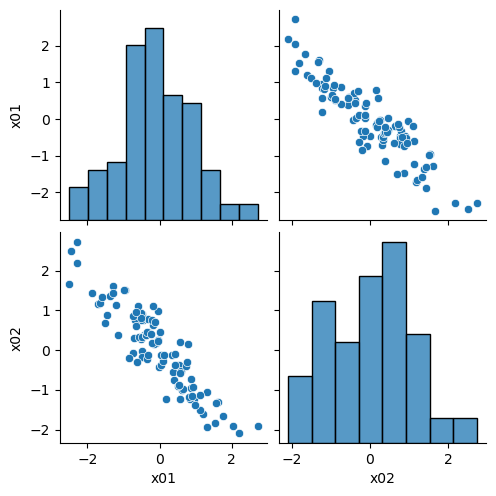

In [34]:
sns.pairplot( data = x_rho_neg_df )
plt.show()

Anti-correlated variables show that increasing values of oen variable are associated with decreasing values of the other variable. Isolating the same lower right corner now reveals observations are present in the region of high `x01` but low `x02`! The upper right corner of the plot is now "empty" becaue of the anti-correlation!

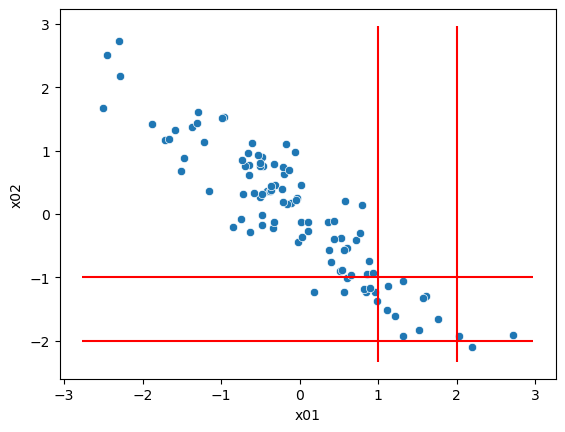

In [35]:
fig, ax = plt.subplots()

sns.scatterplot(data = x_rho_neg_df, x='x01', y='x02', ax=ax)

ax.hlines(y=[-1, -2], xmin = ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red')

ax.vlines(x=[1,2], ymin = ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red')

plt.show()

The sample correlation coefficient is negative! Thus negative correlation coefficients are associated with "negative" or "anti" trends between the two variables!

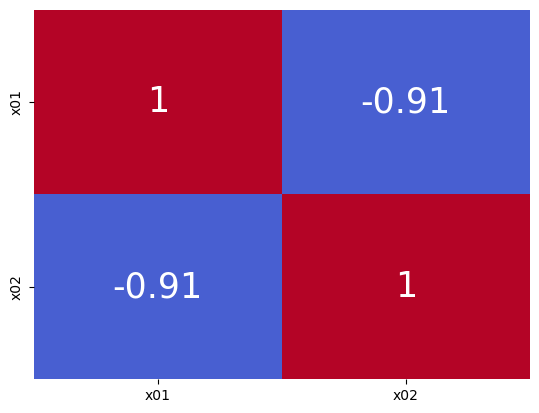

In [36]:
fig, ax = plt.subplots()

sns.heatmap( data = x_rho_neg_df.corr(),
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm', cbar=False,
            annot=True, annot_kws={'size': 25},
            ax=ax)
plt.show()

## Summary
Let's wrap up by combining the three DataFrames together. This way we visualize the scatter plots and correlation plots across the correlation coefficients together. The `corr` column is added to each DataFrame to provide a grouping variable

In [37]:
x_rho_zero_df['corr']= 0.0
x_rho_neg_df['corr'] = -0.9
x_rho_high_df['corr'] = 0.9

In [38]:
df = pd.concat( [x_rho_neg_df, x_rho_zero_df, x_rho_high_df ] )

In [39]:
df

,x01,x02,corr
0,-0.467334,0.763389,-0.9
1,0.966314,-1.235760,-0.9
2,-0.476499,-0.010776,-0.9
3,-0.052935,0.974842,-0.9
4,-1.467094,0.877410,-0.9
...,...,...,...
95,-1.149048,-1.043672,0.9
96,-1.607789,-1.929561,0.9
97,1.287166,1.247264,0.9
98,-0.608196,-0.898570,0.9


The scatter plot between `x01` and `x02` grouped by each correlation coefficient value that generated the data are shown below. Hopefully this figure makes it clear about the differences between "highly" ANTI vorrelated variables, ZERO correlation or UNCORRELATED variables, and highly POSITIVE correlated variables.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


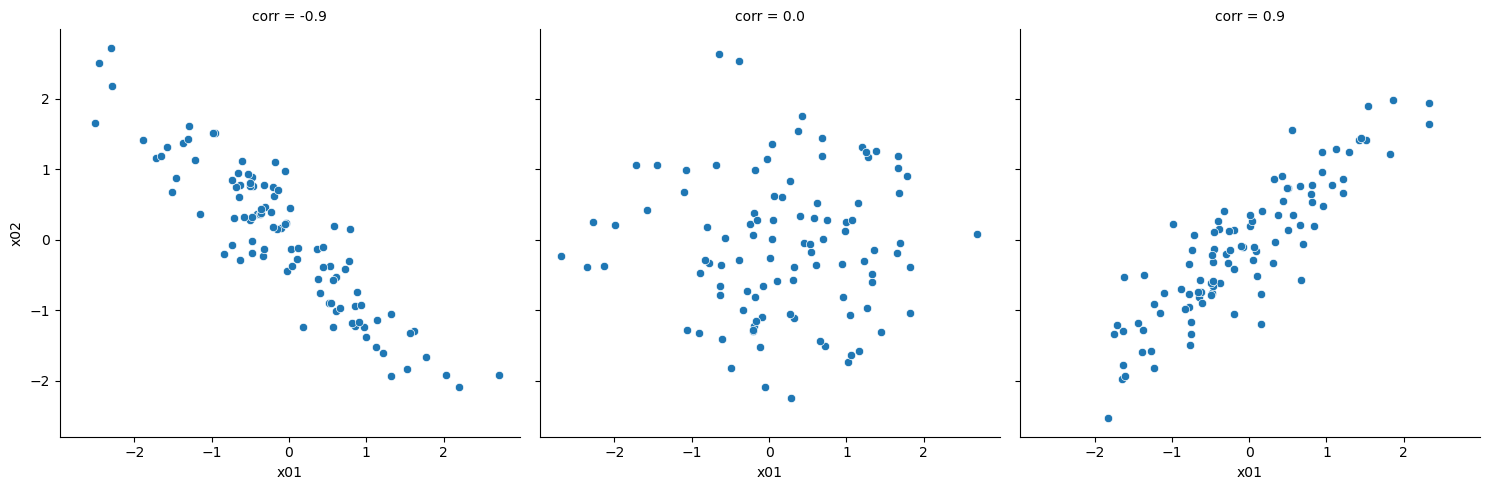

In [40]:
sns.relplot(data = df, x='x01', y='x02', col='corr')
plt.show()

Trend lines are included below to highlight the UNCORRELATED varible have "flat" line

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


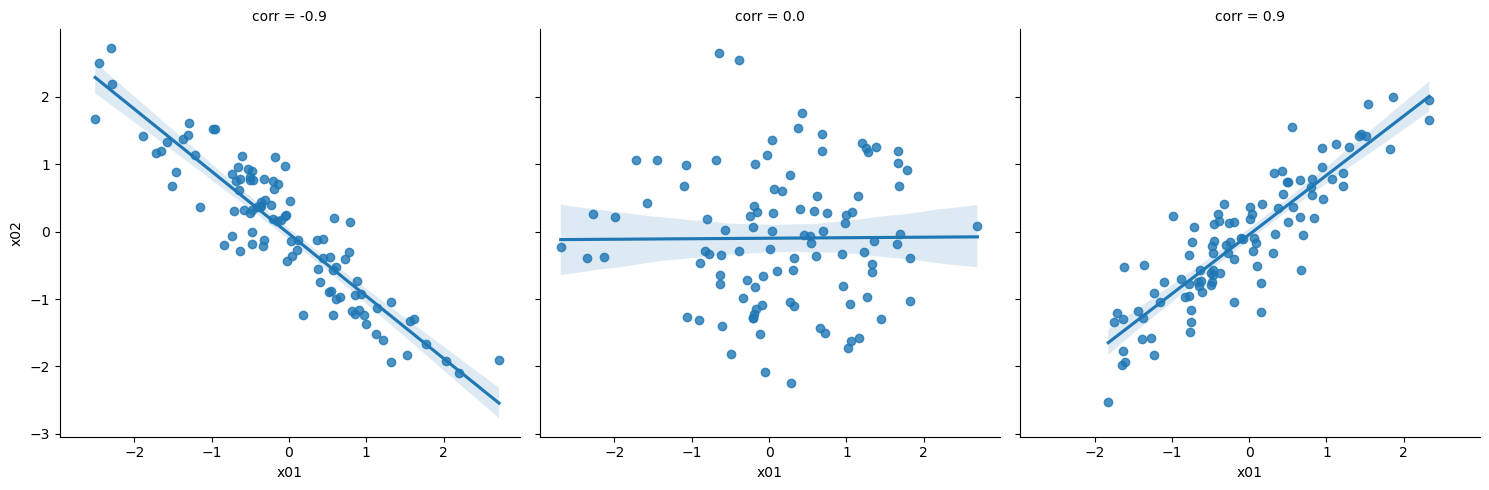

In [41]:
sns.lmplot( data = df, x ='x01', y='x02', col='corr')

plt.show()

The grouped correlation plot is provided below to summarize the sample correlation coefficients associated with the trend directions shown above. The grouped correlation plot is created following the same steps demonstrated in the "M7 Continuous to Continuous relationships: correlation plots" recording. The grouping variableis `corr` rather than `species` because we are **not** working with the `penguins` data set. Also, the facet (subplot) titles labels were changed.

In [42]:
the_groups = df['corr'].unique().tolist()

In [43]:
corr_per_group = df.groupby('corr').corr(numeric_only=True)

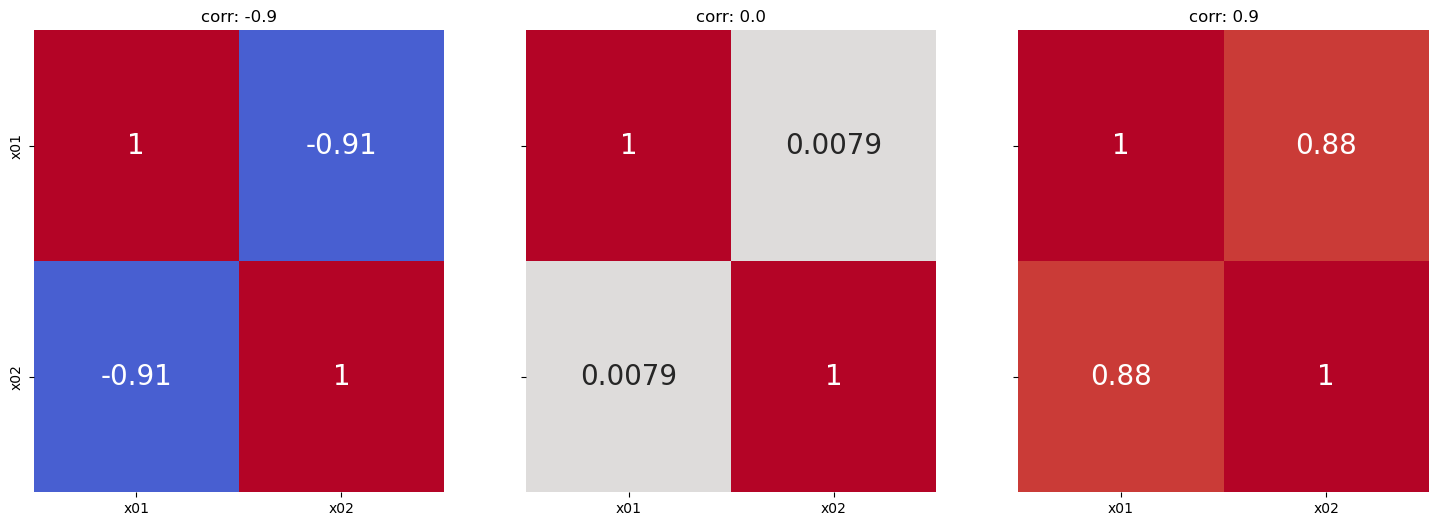

In [45]:
fig, axs = plt.subplots(1, len(the_groups), figsize=(18, 6), sharex=True, sharey=True )

for ix in range(len(the_groups)):
    sns.heatmap( data = corr_per_group.loc[ the_groups[ ix ]],
                vmin=-1, vmax=1, center=0,
                cmap='coolwarm', cbar=False,
                annot=True, annot_kws={'size': 20},
                ax=axs[ix] )
    axs[ ix ].set_title('corr: %1.1f' % the_groups[ ix ] )
plt.show()